In [1]:
import pickle
from PIL import Image
import torch

# Cosmos‑Policy imports. These modules live inside the cloned repository.
from cosmos_policy.experiments.robot.libero.run_libero_eval import PolicyEvalConfig
from cosmos_policy.experiments.robot.cosmos_utils import (
    get_model,
    load_dataset_stats,
    init_t5_text_embeddings_cache,
    get_action
)

# Define the configuration object used for evaluation.
# The PolicyEvalConfig class stores all the command‑line flags that
# the evaluation script would normally receive. Setting values here makes
# the code self‑contained in a notebook.
cfg = PolicyEvalConfig(
    config="cosmos_predict2_2b_480p_libero__inference_only",
    ckpt_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B",
    config_file="cosmos_policy/config/config.py",
    dataset_stats_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_dataset_statistics.json",
    t5_text_embeddings_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_t5_embeddings.pkl",
    use_wrist_image=True,
    use_proprio=True,
    normalize_proprio=True,
    unnormalize_actions=True,
    chunk_size=16,
    num_open_loop_steps=16,
    trained_with_image_aug=True,
    use_jpeg_compression=True,
    flip_images=True,
    num_denoising_steps_action=5,
    num_denoising_steps_future_state=1,
    num_denoising_steps_value=1,
    suite="libero",
    num_queries_best_of_n = 10
)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /workspace-SR006.nfs2/spiridonov/cosmos-policy/.venv/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/workspace-SR006.nfs2/spiridonov/cosmos-policy/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See http

[05-16 07:23:43|CRITICAL|cosmos_policy/_src/predict2/checkpointer/dcp.py:188:<module>] for the back comptiable pytorch! New DefaultLoadPlanner class is created.
Using LIBERO constants:
  NUM_ACTIONS_CHUNK = 16
  ACTION_DIM = 7
  PROPRIO_DIM = 9
If needed, manually set the correct constants in `projects/cosmos/cosmos_policy/constants.py`!


In [2]:
# Load dataset statistics required for scaling proprioception and actions.
dataset_stats = load_dataset_stats(cfg.dataset_stats_path)

# Initialize the T5 text embedding cache with precomputed embeddings.
# This speeds up conversion from task descriptions to embeddings used by the model.
init_t5_text_embeddings_cache(cfg.t5_text_embeddings_path)

File downloaded successfully to: /home/jovyan/.cache/huggingface/hub/models--nvidia--Cosmos-Policy-LIBERO-Predict2-2B/snapshots/cb689ec0e3347c13667d70a78a3447388f5c3bb8/libero_dataset_statistics.json
File downloaded successfully to: /home/jovyan/.cache/huggingface/hub/models--nvidia--Cosmos-Policy-LIBERO-Predict2-2B/snapshots/cb689ec0e3347c13667d70a78a3447388f5c3bb8/libero_t5_embeddings.pkl
Loaded T5 text embeddings from /home/jovyan/.cache/huggingface/hub/models--nvidia--Cosmos-Policy-LIBERO-Predict2-2B/snapshots/cb689ec0e3347c13667d70a78a3447388f5c3bb8/libero_t5_embeddings.pkl onto device cuda:0


In [3]:
# Download the pre‑trained checkpoint from Hugging Face (if not cached)
# and load the model into memory.  The checkpoint specified in cfg.ckpt_path
# corresponds to the 2‑billion‑parameter policy for LIBERO.
model, cosmos_config = get_model(cfg)

# Ensure the model is in evaluation mode and on GPU if available.
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

/workspace-SR006.nfs2/spiridonov/cosmos-policy/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Instantiating pretrained Cosmos model...
Detected HuggingFace repository: nvidia/Cosmos-Policy-LIBERO-Predict2-2B


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 427.54it/s]

Checkpoint downloaded successfully to: /home/jovyan/.cache/huggingface/hub/models--nvidia--Cosmos-Policy-LIBERO-Predict2-2B/snapshots/cb689ec0e3347c13667d70a78a3447388f5c3bb8


[05-16 07:23:47|INFO|cosmos_policy/_src/imaginaire/visualize/video.py:31:<module>] No module named 'ffmpegcv'
[05-16 07:23:47|CRITICAL|cosmos_policy/_src/imaginaire/utils/config_helper.py:192:import_all_modules_from_package] Reloading all modules from package cosmos_policy._src.predict2.configs.video2world.experiment
[05-16 07:23:48|INFO|cosmos_policy/_src/predict2/datasets/augmentor_provider.py:94:augmentor_register] registering video_basic_augmentor_v1...
[05-16 07:23:48|INFO|cosmos_policy/_src/predict2/datasets/augmentor_provider.py:94:augmentor_register] registering video_basic_augmentor_v2...
[05-16 07:23:48|INFO|cosmos_policy/_src/predict2/datasets/augmentor_provider.py:94:augmentor_register] registering noframedrop_nocameramove_video_augmentor_v1...
[05-16 07:23:48|INFO|cosmos_policy/_src/predict2/datasets/augmentor_provider.py:94:augmentor_register] registering nocameramove_video_augmentor_v1...
[05-16 07:23:48|INFO|cosmos_policy/_src/predict2/datasets/augmentor_provider.py:94:

In [4]:
import gc
import torch
gc.collect()

# Очистите кэш CUDA
torch.cuda.empty_cache()
torch.cuda.empty_cache()

In [5]:
with open("cosmos_policy/experiments/robot/libero/sample_libero_10_observation.pkl", "rb") as f:
    observation = pickle.load(f)

In [6]:
# Provide a task description in natural language.  This instructs the policy
# about the goal of the robot.  Students can change this string to any LIBERO task.
task_description = "put both the alphabet soup and the tomato sauce in the basket"

import torch

# Use the get_action function to compute a 16‑step action sequence,
# the predicted future state, and an estimated value (expected reward).
# The 'num_denoising_steps_action' controls the number of diffusion steps used
# for action generation; fewer steps speed up inference at the cost of quality.

with torch.inference_mode():
    result = get_action(
          cfg,
          model,
          dataset_stats,
          observation,
          task_description,
          num_denoising_steps_action=cfg.num_denoising_steps_action,
          generate_future_state_and_value_in_parallel=True,
      )

# Inspect the returned dictionary.
actions = result['actions']               # Predicted actions (16 x 7 array)
# future_states = result['future_state_predictions']  # Predicted future proprio + images
# value_estimate = result['value_prediction']  # Predicted value (scalar)

[05-16 07:24:01|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0


In [7]:
result['generated_latent'].shape

torch.Size([1, 16, 9, 28, 28])

In [8]:
result.keys()

dict_keys(['actions', 'generated_latent', 'orig_clean_latent_frames', 'data_batch', 'latent_indices', 'all_camera_images', 'proprio', 'text_embedding', 'future_image_predictions', 'value_prediction'])

In [9]:
# Print the action chunk for inspection.  Each row corresponds to one time step,
# and columns correspond to x, y, z position deltas, quaternion deltas, and gripper.
import pandas as pd
action_df = pd.DataFrame(actions, columns=[
    "dx", "dy", "dz", "dqx", "dqy", "dqz", "gripper"
])
action_df

,dx,dy,dz,dqx,dqy,dqz,gripper
0,-0.005410,-0.055657,0.001039,-0.000444,0.000150,-0.015325,-0.998989
1,0.009850,-0.033640,0.001055,0.000208,0.000699,-0.012442,-1.000267
2,-0.011882,-0.036674,0.000596,-0.000374,0.000014,-0.011131,-0.997554
3,0.006396,-0.015673,0.000847,-0.000668,0.002905,-0.010105,-1.000058
4,0.025510,-0.067953,0.003427,-0.000743,0.011272,-0.003933,-0.998300
5,0.046553,-0.090105,0.002559,-0.000211,0.026438,-0.005198,-1.000104
6,0.092194,-0.144911,0.008286,-0.001045,0.037674,-0.004373,-0.997386
7,0.121368,-0.214223,0.012982,-0.000832,0.047288,-0.006051,-1.001959
8,0.148047,-0.322465,0.003361,0.003755,0.055778,-0.007287,-1.000562
9,0.165652,-0.399384,0.001235,0.007380,0.059189,-0.007470,-1.001566


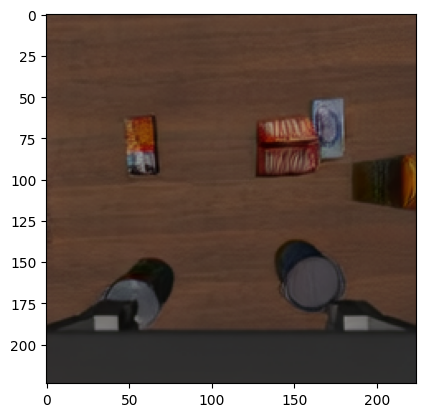

In [10]:
import matplotlib.pyplot as plt

plt.imshow(result['future_image_predictions']['future_wrist_image'])

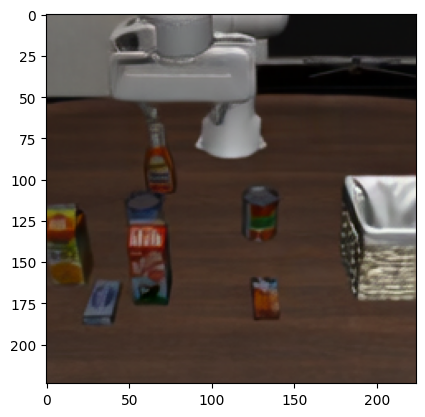

In [11]:
plt.imshow(result['future_image_predictions']['future_image'])

In [12]:
from libero.libero import benchmark

from cosmos_policy.experiments.robot.libero.libero_utils import (
    get_libero_dummy_action,
    get_libero_env,
    get_libero_image,
    get_libero_wrist_image,
    save_rollout_video,
    save_rollout_video_with_future_image_predictions,
)


benchmark.get_benchmark_dict(help=True)

BenchmarkClass = benchmark.get_benchmark('libero_object')
task_suite = BenchmarkClass()  # create an instance

print("Number of tasks in this suite:", task_suite.get_num_tasks())
print("Task names:", task_suite.get_task_names())

task = task_suite.get_task(0)
print("Selected task name:", task.name)
print("Task language description:", task.language)

Available benchmarks:
	libero_spatial
	libero_object
	libero_goal
	libero_90
	libero_10
	libero_100
	libero_mix
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 19

In [14]:
cfg = PolicyEvalConfig(
    config="cosmos_predict2_2b_480p_libero__inference_only",
    ckpt_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B",
    config_file="cosmos_policy/config/config.py",
    dataset_stats_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_dataset_statistics.json",
    t5_text_embeddings_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_t5_embeddings.pkl",
    use_wrist_image=True,
    use_proprio=True,
    normalize_proprio=True,
    unnormalize_actions=True,
    chunk_size=16,
    num_open_loop_steps=16,
    trained_with_image_aug=True,
    use_jpeg_compression=True,
    flip_images=True,
    num_denoising_steps_action=5,
    num_denoising_steps_future_state=1,
    num_denoising_steps_value=1,
    suite="libero",
    seed=195,
    task_suite_name = "libero_10",
)


In [15]:
from libero.libero import benchmark
from cosmos_policy.experiments.robot.libero.libero_utils import (
    get_libero_dummy_action,
    get_libero_env,
    get_libero_image,
    get_libero_wrist_image,
    save_rollout_video,
    save_rollout_video_with_future_image_predictions,
)


suite_name = "libero_10"
BenchmarkClass = benchmark.get_benchmark(suite_name)
task_suite = BenchmarkClass()

task_id = 9
task = task_suite.get_task(task_id)

env, task_description = get_libero_env(task, 'cosmos', resolution=256)

print("Task description:", task_description)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

In [16]:
import torch, numpy as np, importlib
if not getattr(torch.load, "_cosmos_patched", False):
    _glb = []
    for p in ("numpy.core.multiarray._reconstruct", "numpy._core.multiarray._reconstruct"):
        try:
            m, n = p.rsplit(".", 1); _glb.append(getattr(importlib.import_module(m), n))
        except Exception: pass
    for a in ("dtype", "ndarray"):
        try: _glb.append(getattr(np, a))
        except Exception: pass
    try: torch.serialization.add_safe_globals(_glb)
    except Exception: pass
    _orig = torch.load
    def _load(*a, **k):
        k.setdefault("weights_only", False)
        return _orig(*a, **k)
    _load._cosmos_patched = True
    torch.load = _load
    print("torch.load patched: weights_only=False default; safe_globals +", len(_glb))
else:
    print("torch.load already patched")

torch.load patched: weights_only=False default; safe_globals + 4


In [17]:
from cosmos_policy.experiments.robot.libero.run_libero_eval import load_initial_states

initial_states, all_initial_states = load_initial_states(cfg, task_suite, task_id)

INFO:cosmos_policy.experiments.robot.robot_utils:Using default initial states


Using default initial states


In [18]:
import os
from cosmos_policy.experiments.robot.libero.run_libero_eval import PolicyEvalConfig, load_initial_states, run_episode
from cosmos_policy.utils.utils import set_seed_everywhere
from libero.libero import benchmark
from cosmos_policy.experiments.robot.libero.libero_utils import (
    get_libero_dummy_action,
    get_libero_env,
    get_libero_image,
    get_libero_wrist_image,
    save_rollout_video,
    save_rollout_video_with_future_image_predictions,
)

FAILED = [
# ============ CURATED for frame investigation ============
# A) OVERCONFIDENT appearance-OOD: value≈0.9 but FAILS (proposal core)
    ("libero_10",  233, 0),  # white_mug/tb/5  mean_v=0.88 last_v=1.00 max_v=1.00
    # ("libero_10",  235, 0),  # white_mug/tb/8  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  225, 0),  # white_mug/tb/17  mean_v=0.87 last_v=0.99 max_v=1.00
    # ("libero_10",  213, 0),  # white_mug/table/6  mean_v=0.86 last_v=1.00 max_v=1.00
    # ("libero_10",  193, 0),  # white_mug/table/1  mean_v=0.83 last_v=0.87 max_v=1.00
    # ("libero_10",   97, 0),  # yellow_mug_microwave/table/9  mean_v=0.75 last_v=1.00 max_v=1.00
# B) CONTRAST: calibrated fails — value correctly LOW (model 'knows')
    # ("libero_10", 2028, 0),  # moka_pots/add/24  mean_v=0.19 last_v=0.52 max_v=0.53
    # ("libero_10", 2030, 0),  # moka_pots/add/26  mean_v=0.18 last_v=0.48 max_v=0.53
    # ("libero_10", 2022, 0),  # moka_pots/add/14  mean_v=0.17 last_v=0.50 max_v=0.52

# ============ FULL 61-fail reference (all commented) ============
    # ("libero_10",  233, 0),  # white_mug/tb/5  mean_v=0.88 last_v=1.00 max_v=1.00
    # ("libero_10",  235, 0),  # white_mug/tb/8  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  225, 0),  # white_mug/tb/17  mean_v=0.87 last_v=0.99 max_v=1.00
    # ("libero_10",  223, 0),  # white_mug/tb/15  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  234, 0),  # white_mug/tb/6  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  224, 0),  # white_mug/tb/16  mean_v=0.87 last_v=0.99 max_v=1.00
    # ("libero_10",  222, 0),  # white_mug/tb/14  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  219, 0),  # white_mug/tb/11  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  220, 0),  # white_mug/tb/12  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  221, 0),  # white_mug/tb/13  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  236, 0),  # white_mug/tb/9  mean_v=0.87 last_v=1.00 max_v=1.00
    # ("libero_10",  218, 0),  # white_mug/tb/10  mean_v=0.86 last_v=0.93 max_v=1.00
    # ("libero_10",  231, 0),  # white_mug/tb/3  mean_v=0.85 last_v=1.00 max_v=1.00
    # ("libero_10",  232, 0),  # white_mug/tb/4  mean_v=0.84 last_v=1.00 max_v=1.00
    # ("libero_10",  128, 0),  # moka_pots/tb/15  mean_v=0.19 last_v=0.17 max_v=0.53
    # ("libero_10",  134, 0),  # moka_pots/tb/21  mean_v=0.19 last_v=0.40 max_v=0.55
    # ("libero_10",  126, 0),  # moka_pots/tb/12  mean_v=0.19 last_v=0.31 max_v=0.54
    # ("libero_10",  135, 0),  # moka_pots/tb/3  mean_v=0.18 last_v=0.28 max_v=0.54
    # ("libero_10",  132, 0),  # moka_pots/tb/2  mean_v=0.18 last_v=0.28 max_v=0.54
    # ("libero_10",  136, 0),  # moka_pots/tb/9  mean_v=0.18 last_v=0.12 max_v=0.55
    # ("libero_10",  213, 0),  # white_mug/table/6  mean_v=0.86 last_v=1.00 max_v=1.00
    # ("libero_10",  193, 0),  # white_mug/table/1  mean_v=0.83 last_v=0.87 max_v=1.00
    # ("libero_10",  201, 0),  # white_mug/table/18  mean_v=0.73 last_v=0.98 max_v=1.00
    # ("libero_10",  212, 0),  # white_mug/table/5  mean_v=0.73 last_v=1.00 max_v=1.00
    # ("libero_10",  209, 0),  # white_mug/table/27  mean_v=0.73 last_v=1.00 max_v=1.00
    # ("libero_10",  199, 0),  # white_mug/table/16  mean_v=0.72 last_v=1.00 max_v=1.00
    # ("libero_10",  205, 0),  # white_mug/table/23  mean_v=0.72 last_v=1.00 max_v=1.00
    # ("libero_10",  200, 0),  # white_mug/table/17  mean_v=0.72 last_v=1.00 max_v=1.00
    # ("libero_10",  196, 0),  # white_mug/table/13  mean_v=0.72 last_v=1.00 max_v=1.00
    # ("libero_10",  215, 0),  # white_mug/table/8  mean_v=0.72 last_v=1.00 max_v=1.00
    # ("libero_10",  214, 0),  # white_mug/table/7  mean_v=0.67 last_v=1.00 max_v=1.00
    # ("libero_10",  206, 0),  # white_mug/table/24  mean_v=0.65 last_v=0.98 max_v=1.00
    # ("libero_10",  194, 0),  # white_mug/table/10  mean_v=0.54 last_v=1.00 max_v=1.00
    # ("libero_10",  204, 0),  # white_mug/table/22  mean_v=0.35 last_v=0.73 max_v=0.73
    # ("libero_10",   97, 0),  # yellow_mug_microwave/table/9  mean_v=0.75 last_v=1.00 max_v=1.00
    # ("libero_10",   80, 0),  # yellow_mug_microwave/table/15  mean_v=0.71 last_v=1.00 max_v=1.00
    # ("libero_10",   87, 0),  # yellow_mug_microwave/table/25  mean_v=0.68 last_v=1.00 max_v=1.00
    # ("libero_10",   92, 0),  # yellow_mug_microwave/table/4  mean_v=0.62 last_v=1.00 max_v=1.00
    # ("libero_10",   86, 0),  # yellow_mug_microwave/table/24  mean_v=0.62 last_v=0.42 max_v=1.00
    # ("libero_10",  112, 0),  # moka_pots/table/17  mean_v=0.50 last_v=1.00 max_v=1.00
    # ("libero_10",  115, 0),  # moka_pots/table/21  mean_v=0.25 last_v=0.38 max_v=1.00
    # ("libero_10",  117, 0),  # moka_pots/table/23  mean_v=0.24 last_v=0.25 max_v=0.54
    # ("libero_10",  114, 0),  # moka_pots/table/2  mean_v=0.19 last_v=0.37 max_v=0.53
    # ("libero_10",  108, 0),  # moka_pots/table/12  mean_v=0.17 last_v=0.21 max_v=0.54
    # ("libero_10",  119, 0),  # moka_pots/table/27  mean_v=0.13 last_v=0.19 max_v=0.26
    # ("libero_10",  120, 0),  # moka_pots/table/28  mean_v=0.13 last_v=0.15 max_v=0.26
    # ("libero_10",  113, 0),  # moka_pots/table/19  mean_v=0.13 last_v=0.15 max_v=0.32
    # ("libero_10",  118, 0),  # moka_pots/table/24  mean_v=0.12 last_v=0.12 max_v=0.21
    # ("libero_10", 2143, 0),  # white_mug/add/28  mean_v=0.57 last_v=0.31 max_v=1.00
    # ("libero_10", 2140, 0),  # white_mug/add/25  mean_v=0.38 last_v=0.52 max_v=0.66
    # ("libero_10", 2026, 0),  # moka_pots/add/21  mean_v=0.45 last_v=0.29 max_v=1.00
    # ("libero_10", 2033, 0),  # moka_pots/add/30  mean_v=0.35 last_v=0.37 max_v=1.00
    # ("libero_10", 2029, 0),  # moka_pots/add/25  mean_v=0.21 last_v=0.56 max_v=0.56
    # ("libero_10", 2024, 0),  # moka_pots/add/19  mean_v=0.20 last_v=0.54 max_v=0.54
    # ("libero_10", 2032, 0),  # moka_pots/add/29  mean_v=0.20 last_v=0.51 max_v=0.55
    # ("libero_10", 2028, 0),  # moka_pots/add/24  mean_v=0.19 last_v=0.52 max_v=0.53
    # ("libero_10", 2030, 0),  # moka_pots/add/26  mean_v=0.18 last_v=0.48 max_v=0.53
    # ("libero_10", 2022, 0),  # moka_pots/add/14  mean_v=0.17 last_v=0.50 max_v=0.52
    # ("libero_10", 2103, 0),  # cream_cheese/add/23  mean_v=0.19 last_v=0.32 max_v=0.32
    # ("libero_10", 2353, 0),  # yellow_mug_microwave/light/29  mean_v=0.69 last_v=1.00 max_v=1.00
    # ("libero_10", 2397, 0),  # moka_pots/light/49  mean_v=0.50 last_v=1.00 max_v=1.00
]
SEEDS = [195]

os.environ["DETERMINISTIC"] = "True"
import io, contextlib, logging

logging.disable(logging.INFO)

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    for seed in SEEDS:
        for suite_name, task_id, state_id in FAILED:
            cfg = PolicyEvalConfig(
                config="cosmos_predict2_2b_480p_libero__inference_only",
                ckpt_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B",
                config_file="cosmos_policy/config/config.py",
                dataset_stats_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_dataset_statistics.json",
                t5_text_embeddings_path="nvidia/Cosmos-Policy-LIBERO-Predict2-2B/libero_t5_embeddings.pkl",
                use_wrist_image=True, use_proprio=True,
                normalize_proprio=True, unnormalize_actions=True,
                chunk_size=16, num_open_loop_steps=16,
                trained_with_image_aug=True, use_jpeg_compression=True, flip_images=True,
                num_denoising_steps_action=5,
                num_denoising_steps_future_state=1,
                num_denoising_steps_value=1,
                suite="libero",
                task_suite_name=suite_name,
                seed=seed,
                deterministic=True,
                deterministic_reset=True, deterministic_reset_seed=0,
                num_queries_best_of_n=5,
            )
            task_suite = benchmark.get_benchmark(suite_name)()
            task = task_suite.get_task(task_id)
            env, task_description = get_libero_env(task, "cosmos", resolution=256)
            initial_states, _ = load_initial_states(cfg, task_suite, task_id)
            set_seed_everywhere(cfg.seed)
            success, replay_images, replay_wrist_images, future_image_predictions_list, collected_data = run_episode(
                cfg=cfg, env=env, task_description=task_description,
                model=model, planning_model=None,
                dataset_stats=dataset_stats, worker_pool=None,
                resize_size=224, initial_state=initial_states[state_id],
            )
            print(f"seed={seed} task_id={task_id} state_id={state_id} -> success={success}",
                  file=__import__('sys').__stdout__)
logging.disable(logging.NOTSET)

[05-16 07:25:25|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:25|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:26|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:26|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:27|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:28|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:29|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:29|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:29|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:25:30|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori

In [19]:
import numpy as np

future_primary_image_predictions = np.asarray([x["future_image"] for x in future_image_predictions_list])
future_wrist_image_predictions = np.asarray([x["future_wrist_image"] for x in future_image_predictions_list])


save_rollout_video_with_future_image_predictions(
            replay_images,
            32,
            success=success,
            task_description=task_description,
            chunk_size=cfg.chunk_size,
            num_open_loop_steps=cfg.num_open_loop_steps,
            rollout_wrist_images=replay_wrist_images,
            future_primary_image_predictions=future_primary_image_predictions,
            future_wrist_image_predictions=future_wrist_image_predictions,
            show_diff=True,
        )

Saved rollout MP4 at path ./rollouts/2026_05_16/2026_05_16-07_23_43--with_future_img--episode=32--success=False--task=put_the_white_mug_on_the_left_plate.mp4


'./rollouts/2026_05_16/2026_05_16-07_23_43--with_future_img--episode=32--success=False--task=put_the_white_mug_on_the_left_plate.mp4'

In [20]:
suite_name = "libero_10"
BenchmarkClass = benchmark.get_benchmark(suite_name)
task_suite = BenchmarkClass()

task_id = 233
task = task_suite.get_task(task_id)

env, task_description = get_libero_env(task, 'cosmos', resolution=256)

print("Task description:", task_description)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

Task description: put the white mug on the left plate and put the yellow and white mug on the right plate tb 5


In [21]:
obs = env.reset()

frames = []
wrist_frames = []

max_timesteps = 300

done = False
t = 0

In [22]:
import numpy as np
from cosmos_policy.experiments.robot.cosmos_utils import get_action
from cosmos_policy.experiments.robot.libero.libero_utils import get_libero_image, get_libero_wrist_image

while not done and t < max_timesteps:
    primary_img = get_libero_image(obs, flip_images=cfg.flip_images)
    wrist_img = get_libero_wrist_image(obs, flip_images=cfg.flip_images)
    proprio = np.concatenate((obs["robot0_gripper_qpos"],
                              obs["robot0_eef_pos"],
                              obs["robot0_eef_quat"]))

    observation = {
        "primary_image": primary_img,
        "wrist_image": wrist_img,
        "proprio": proprio,
    }

    result = get_action(
        cfg,
        model,
        dataset_stats,
        observation,
        task_description,
        num_denoising_steps_action=cfg.num_denoising_steps_action,
        generate_future_state_and_value_in_parallel=True,
    )
    actions = result["actions"]

    for action in actions:
        obs, reward, done, info = env.step(action)

        frames.append(get_libero_image(obs, flip_images=cfg.flip_images))
        wrist_frames.append(get_libero_wrist_image(obs, flip_images=cfg.flip_images))

        t += 1
        if done or t >= max_timesteps:
            break
    print(task_description)

print("Episode finished:", done, "| timesteps:", t)

[05-16 07:27:50|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0


put the white mug on the left plate and put the yellow and white mug on the right plate tb 5
[05-16 07:27:51|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
put the white mug on the left plate and put the yellow and white mug on the right plate tb 5
[05-16 07:27:53|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
put the white mug on the left plate and put the yellow and white mug on the right plate tb 5
[05-16 07:27:54|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
put the white mug on the left plate and put the yellow and white mug on the right plate tb 5
[05-16 07:27:56|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
put the white mug on the left plate and put the yellow and white mug on the right plate tb 5
[05-16 07:27:57|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
put the white mug on the 

In [23]:
result.keys()

dict_keys(['actions', 'generated_latent', 'orig_clean_latent_frames', 'data_batch', 'latent_indices', 'all_camera_images', 'proprio', 'text_embedding', 'future_image_predictions', 'value_prediction'])

In [24]:
result['latent_indices']

{'action_latent_idx': 4,
 'future_proprio_latent_idx': 5,
 'future_wrist_image_latent_idx': 6,
 'future_wrist_image2_latent_idx': -1,
 'future_image_latent_idx': 7,
 'future_image2_latent_idx': -1,
 'value_latent_idx': 8}

In [25]:
result['generated_latent'].shape

torch.Size([1, 16, 9, 28, 28])

In [26]:
result['generated_latent'][:, result['latent_indices']['future_proprio_latent_idx']].shape

torch.Size([1, 9, 28, 28])

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from cosmos_policy.constants import ACTION_DIM, NUM_ACTIONS_CHUNK, PROPRIO_DIM
from cosmos_policy.experiments.robot.cosmos_utils import (
    extract_action_chunk_from_latent_sequence,
    extract_value_from_latent_sequence,
    undo_latent_injection,
)

TEMPORAL_COMPRESSION = 4
def latent_to_pixel_idx(li):
    return 0 if li == 0 else (li - 1) * TEMPORAL_COMPRESSION + 1

SLOT_NAMES = [
    "blank",
    "curr_proprio",
    "curr_wrist",
    "curr_primary",
    "action",
    "fut_proprio",
    "fut_wrist",
    "fut_primary",
    "value",
]
SCALAR_SLOTS = {1, 4, 5, 8}   # имеют "растеризованные" скаляры
IMAGE_SLOTS  = {2, 3, 6, 7}   # настоящие image latents

latent = result["generated_latent"]               # (1, 16, 9, 28, 28)
orig_clean = result["orig_clean_latent_frames"]
print(f"latent dtype={latent.dtype} shape={tuple(latent.shape)}  device={latent.device}")
for i, n in enumerate(SLOT_NAMES):
    s = latent[0, :, i].float()
    print(f"  slot {i} [{n:>13s}]   mean={s.mean():+.3f}  std={s.std():.3f}  min={s.min():+.3f}  max={s.max():+.3f}  pixel_idx={latent_to_pixel_idx(i)}")

latent dtype=torch.float32 shape=(1, 16, 9, 28, 28)  device=cuda:0
  slot 0 [        blank]   mean=-0.154  std=0.723  min=-1.531  max=+1.047  pixel_idx=0
  slot 1 [ curr_proprio]   mean=+0.198  std=0.598  min=-0.902  max=+1.031  pixel_idx=1
  slot 2 [   curr_wrist]   mean=+0.048  std=0.948  min=-3.031  max=+3.344  pixel_idx=5
  slot 3 [ curr_primary]   mean=+0.033  std=0.849  min=-2.812  max=+2.281  pixel_idx=9
  slot 4 [       action]   mean=-0.178  std=0.347  min=-1.052  max=+0.152  pixel_idx=13
  slot 5 [  fut_proprio]   mean=+0.187  std=0.581  min=-0.924  max=+1.051  pixel_idx=17
  slot 6 [    fut_wrist]   mean=+0.062  std=0.943  min=-3.203  max=+3.524  pixel_idx=21
  slot 7 [  fut_primary]   mean=+0.037  std=0.788  min=-2.621  max=+2.205  pixel_idx=25
  slot 8 [        value]   mean=+0.998  std=0.009  min=+0.953  max=+1.040  pixel_idx=29


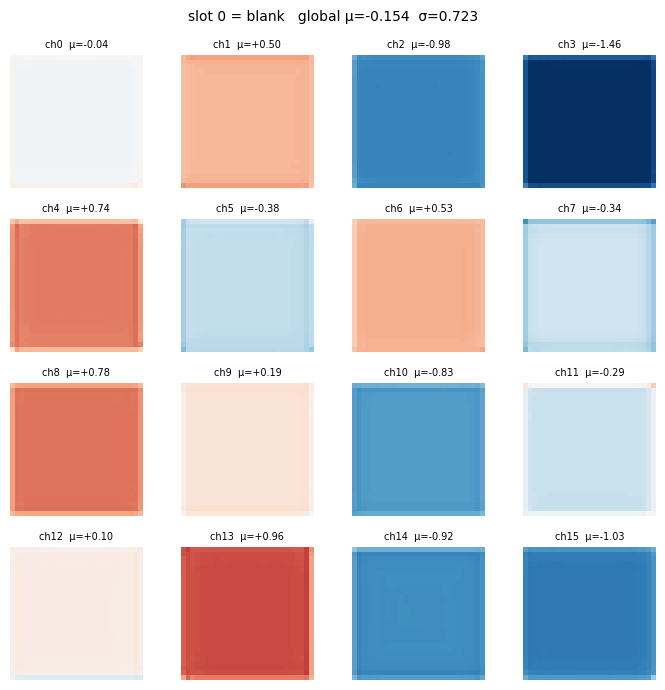

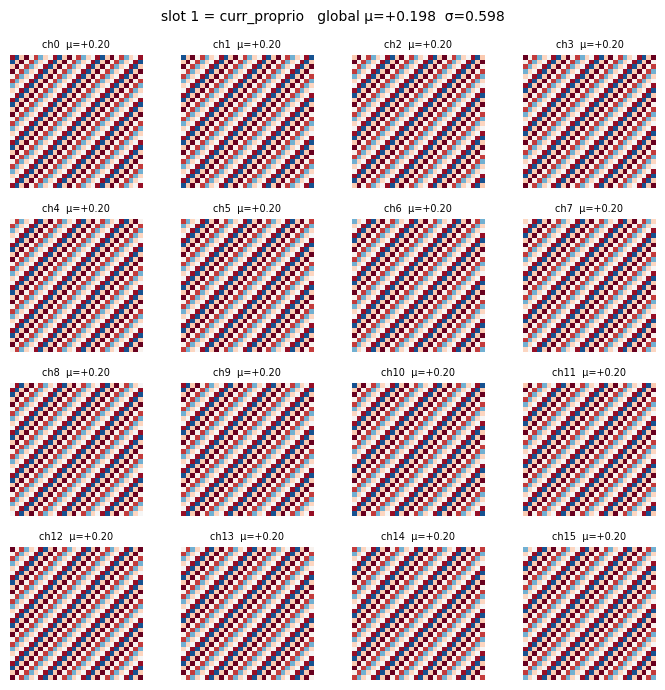

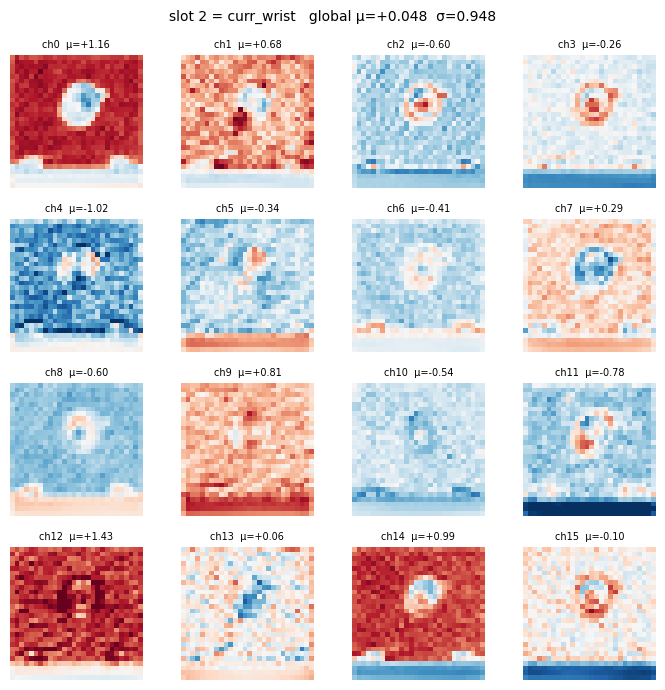

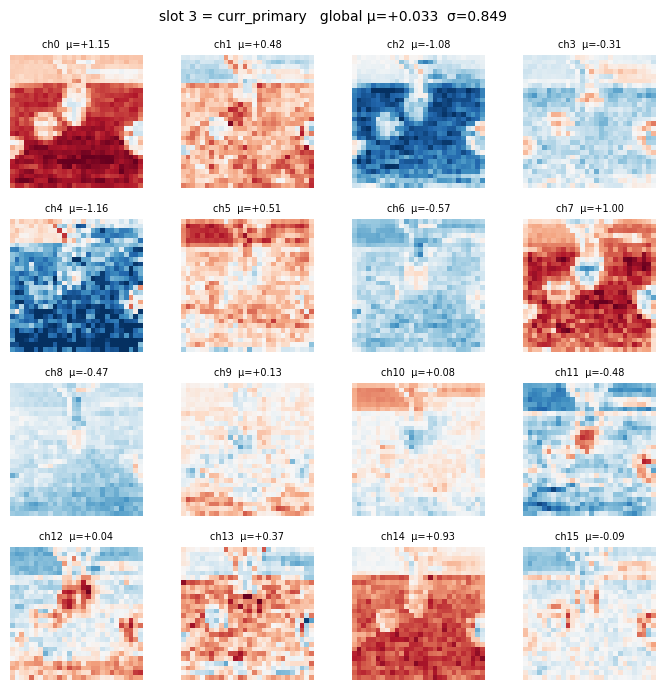

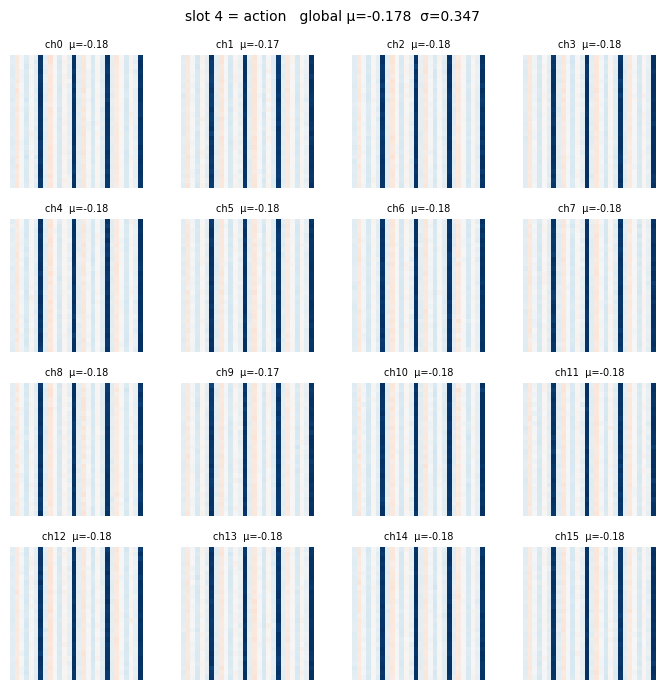

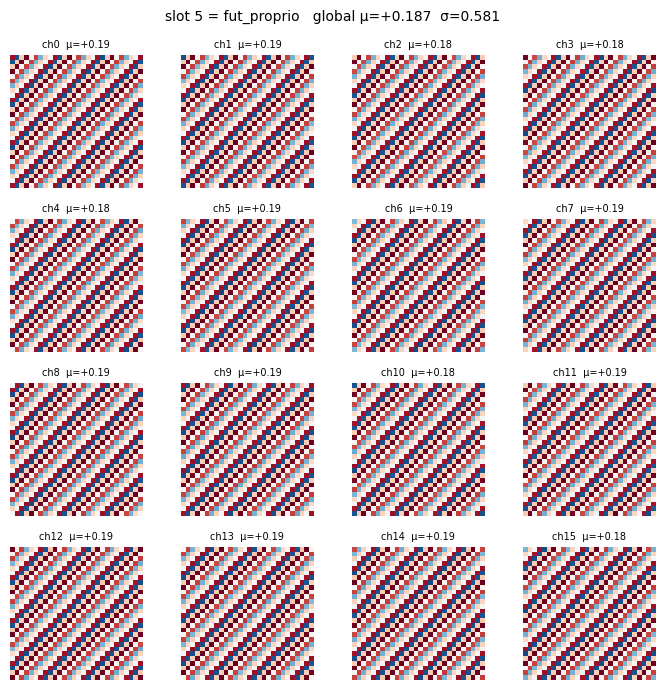

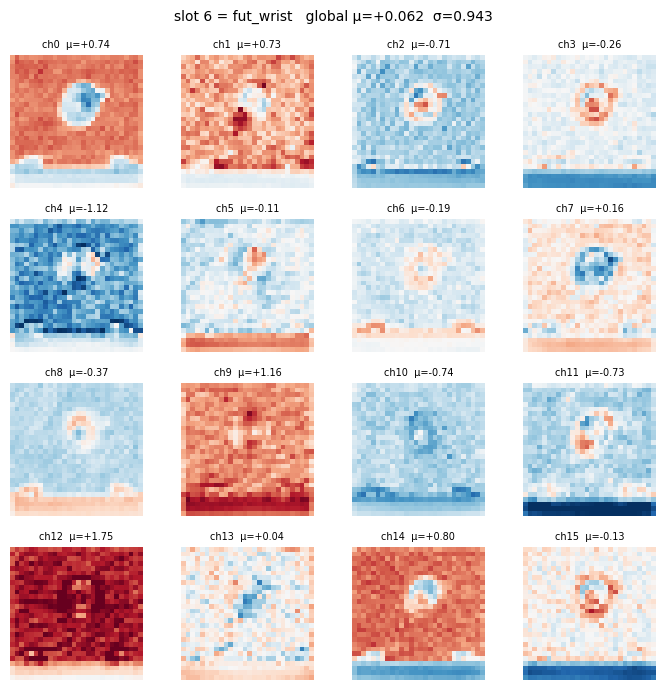

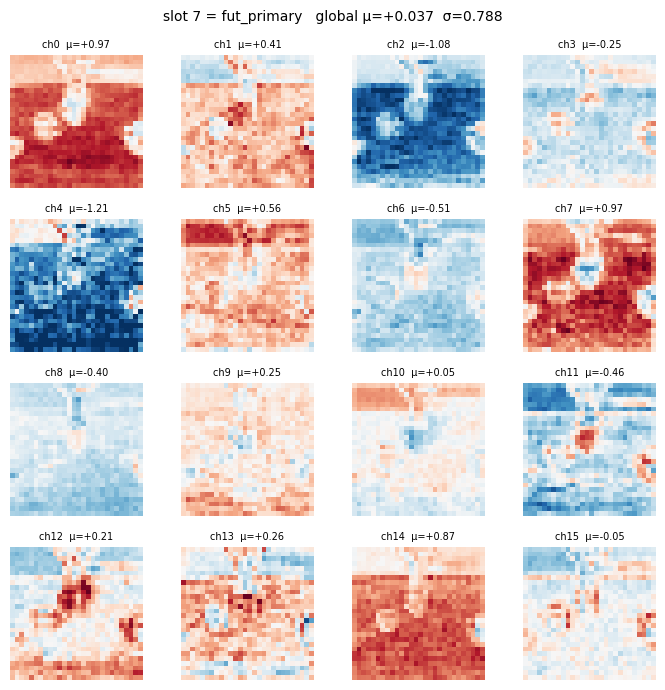

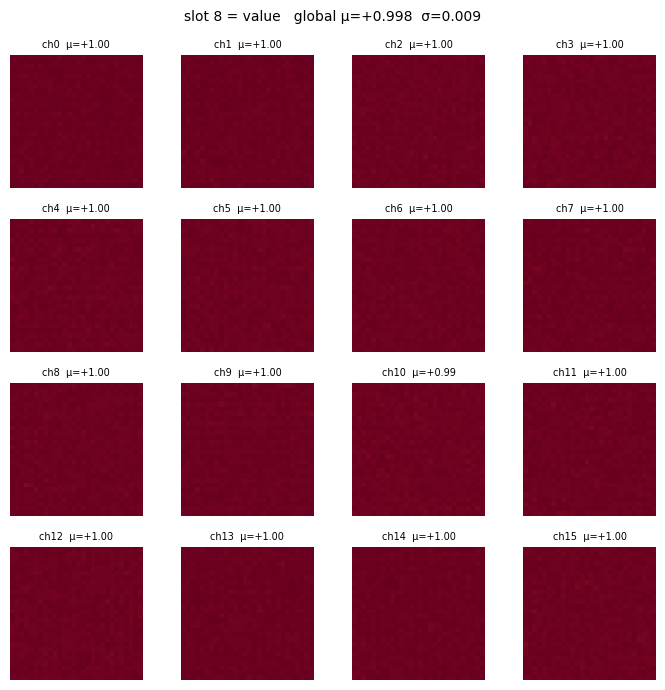

In [28]:
def show_slot_channels(slot_tensor, title):
    """slot_tensor: (16, 28, 28) torch tensor"""
    s = slot_tensor.float().cpu().numpy()
    vmax = float(np.percentile(np.abs(s), 99))   # squash outliers for stable colorbar
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for ch in range(16):
        ax = axes[ch // 4, ch % 4]
        ax.imshow(s[ch], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"ch{ch}  μ={s[ch].mean():+.2f}", fontsize=7)
        ax.axis("off")
    fig.suptitle(f"{title}   global μ={s.mean():+.3f}  σ={s.std():.3f}", fontsize=10)
    plt.tight_layout(); plt.show()

for i, n in enumerate(SLOT_NAMES):
    show_slot_channels(latent[0, :, i], f"slot {i} = {n}")

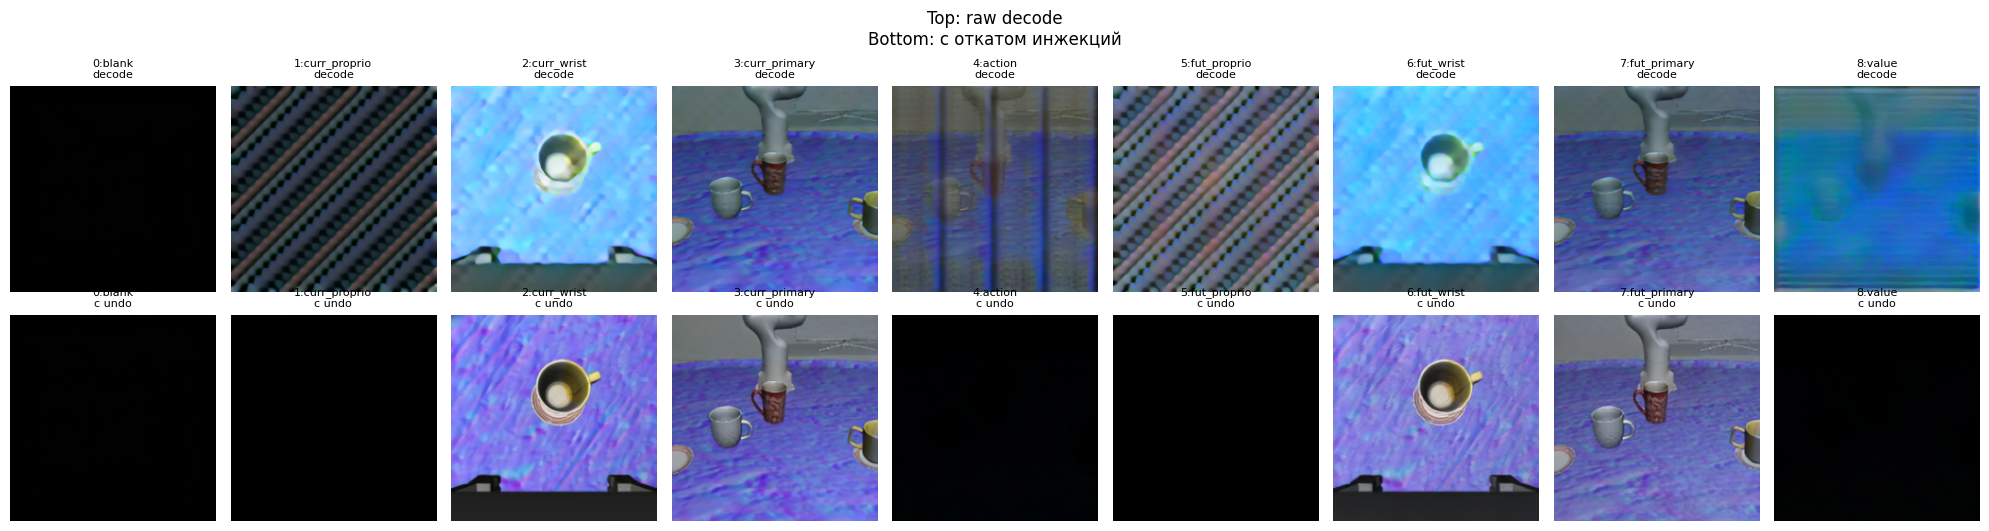

In [29]:
def decode_to_uint8(latent_5d):
    """(1,16,9,28,28) bf16 -> (33, 224, 224, 3) uint8"""
    with torch.inference_mode():
        dec = model.decode(latent_5d)                                # (1,3,33,224,224) in [-1,1]
    img = ((dec + 1.0) * 127.5).clamp(0, 255).byte()
    return img[0].permute(1, 2, 3, 0).cpu().numpy()                  # (33,224,224,3)

raw_rgb = decode_to_uint8(latent.clone())

INDICES_TO_REPLACE = [0, 1, 4, 5, 8]   # blank, curr_proprio, action, fut_proprio, value
clean_sample = undo_latent_injection(latent.clone(), orig_clean, INDICES_TO_REPLACE)
clean_rgb = decode_to_uint8(clean_sample)

# Сравнение по каждому слоту
fig, axes = plt.subplots(2, 9, figsize=(20, 5.5))
for i, n in enumerate(SLOT_NAMES):
    px = latent_to_pixel_idx(i)
    axes[0, i].imshow(raw_rgb[px]);   axes[0, i].set_title(f"{i}:{n}\ndecode", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(clean_rgb[px]); axes[1, i].set_title(f"{i}:{n}\nс undo",     fontsize=8); axes[1, i].axis("off")
plt.suptitle("Top: raw decode\nBottom: с откатом инжекций")
plt.tight_layout(); plt.show()

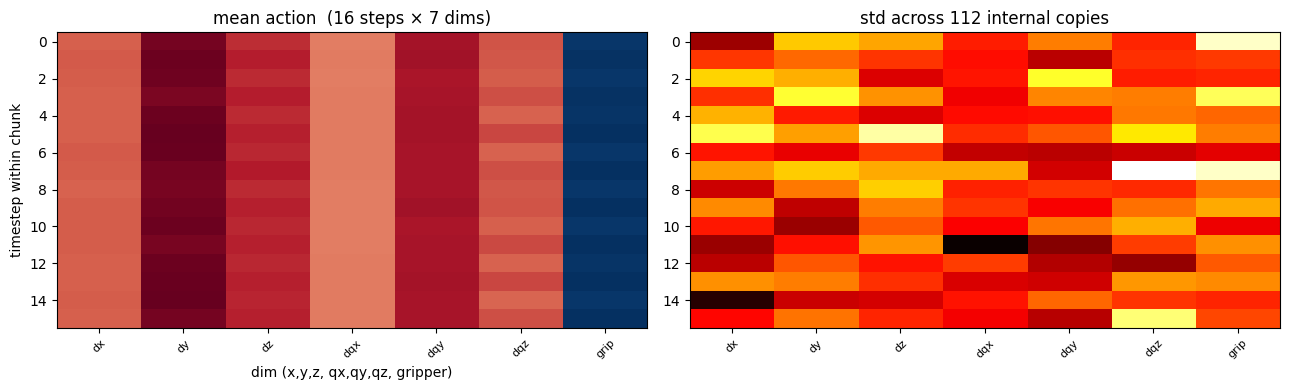

action: max-std = 0.0162,  mean-std = 0.0125


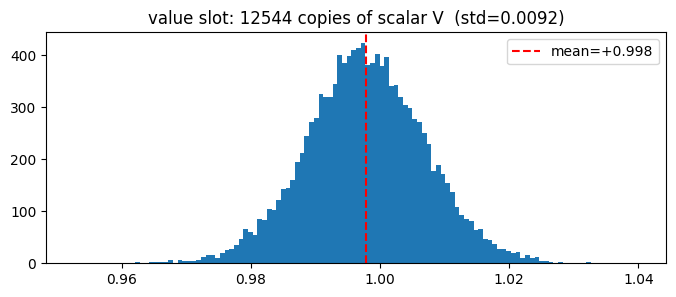

value (normalized [-1,+1]): mean=+0.9978, std=0.0092
value rescaled to [0,1]:     0.9989  (это то же, что result['value_prediction'])
future proprio:
  mean per dim: [ 0.862 -0.887  0.255  0.998  0.03   0.693 -0.479  0.222 -0.009]
  std  per dim: [0.011 0.011 0.01  0.012 0.01  0.012 0.014 0.01  0.01 ]


In [30]:
ai = result["latent_indices"]["action_latent_idx"]
vi = result["latent_indices"]["value_latent_idx"]
pi = result["latent_indices"]["future_proprio_latent_idx"]

def unpack_repeats(slot_3d, item_dim):
    """slot_3d: (16,28,28). Возвращает (n_copies, item_dim), где item_dim = 112 для action и т.д."""
    flat = slot_3d.float().flatten()
    n = flat.numel() // item_dim
    return flat[: n * item_dim].reshape(n, item_dim).cpu().numpy()

# --- ACTION ---
action_copies = unpack_repeats(latent[0, :, ai], NUM_ACTIONS_CHUNK * ACTION_DIM)   # (112, 112)
action_copies = action_copies.reshape(-1, NUM_ACTIONS_CHUNK, ACTION_DIM)           # (112, 16, 7)
action_mean = action_copies.mean(axis=0)   # final action chunk
action_std  = action_copies.std(axis=0)    # per-step per-dim uncertainty

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(action_mean, aspect="auto", cmap="RdBu_r"); axes[0].set_title("mean action  (16 steps × 7 dims)")
axes[0].set_xlabel("dim (x,y,z, qx,qy,qz, gripper)"); axes[0].set_ylabel("timestep within chunk")
axes[1].imshow(action_std,  aspect="auto", cmap="hot");   axes[1].set_title("std across 112 internal copies")
for ax in axes:
    ax.set_xticks(range(7)); ax.set_xticklabels(["dx","dy","dz","dqx","dqy","dqz","grip"], rotation=45, fontsize=8)
plt.tight_layout(); plt.show()
print(f"action: max-std = {action_std.max():.4f},  mean-std = {action_std.mean():.4f}")

# --- VALUE ---
value_elems = latent[0, :, vi].float().flatten().cpu().numpy()   # 12544 элементов, все должны быть ~ V(s)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(value_elems, bins=120); ax.axvline(value_elems.mean(), color="r", ls="--", label=f"mean={value_elems.mean():+.3f}")
ax.set_title(f"value slot: 12544 copies of scalar V  (std={value_elems.std():.4f})")
ax.legend(); plt.show()
print(f"value (normalized [-1,+1]): mean={value_elems.mean():+.4f}, std={value_elems.std():.4f}")
print(f"value rescaled to [0,1]:     {(value_elems.mean()+1)/2:.4f}  (это то же, что result['value_prediction'])")

# --- FUTURE PROPRIO ---
proprio_copies = unpack_repeats(latent[0, :, pi], PROPRIO_DIM)   # (~1393, 9)
print("future proprio:")
print(f"  mean per dim: {proprio_copies.mean(axis=0)}")
print(f"  std  per dim: {proprio_copies.std(axis=0)}")

[05-16 07:29:06|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0


[05-16 07:29:06|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:07|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:07|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:08|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:08|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:09|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:29:09|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
value ensemble: mean=0.999  std=0.000  min=0.999  q10=0.999
action ensemble std: max=0.0151, mean=0.0040


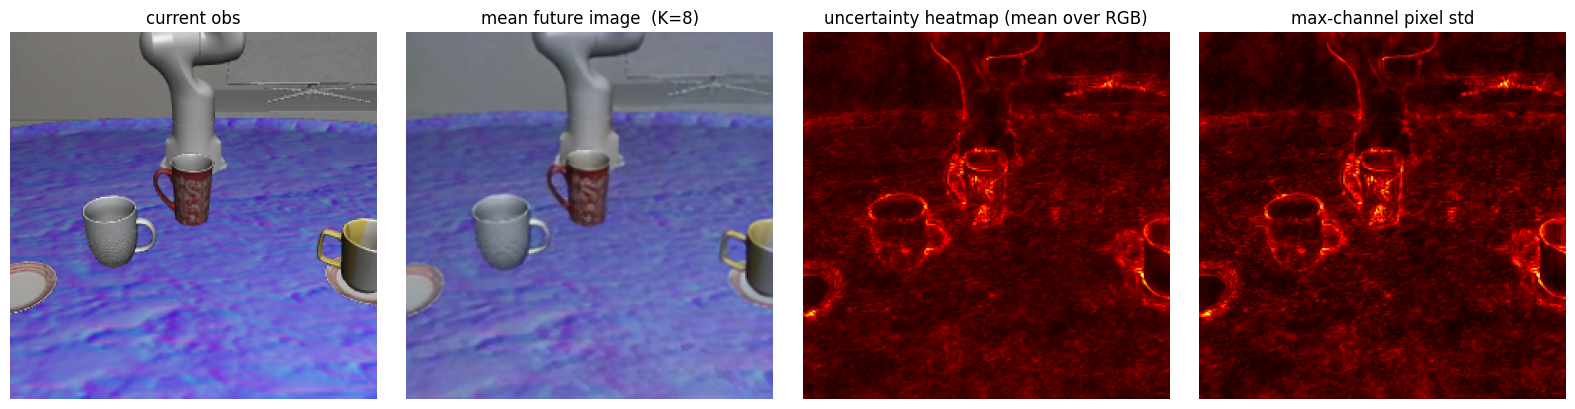

In [31]:
from cosmos_policy.experiments.robot.cosmos_utils import get_action

K = 8
seeds = list(range(100, 100 + K))
ensemble = []
for s in seeds:
    r = get_action(
        cfg, model, dataset_stats, observation, task_description,
        seed=s, num_denoising_steps_action=cfg.num_denoising_steps_action,
        generate_future_state_and_value_in_parallel=True,
    )
    ensemble.append(r)

# (1) value ensemble
vals = np.array([r["value_prediction"] for r in ensemble])
print(f"value ensemble: mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min():.3f}  q10={np.quantile(vals,0.1):.3f}")

# (2) actions ensemble — std per timestep × dim
acts = np.stack([np.array(r["actions"]) for r in ensemble])              # (K, 16, 7)
acts_std = acts.std(axis=0)
print(f"action ensemble std: max={acts_std.max():.4f}, mean={acts_std.mean():.4f}")

# (3) future-image ensemble
imgs = np.stack([r["future_image_predictions"]["future_image"] for r in ensemble]).astype(np.float32)   # (K, 224, 224, 3)
img_mean = imgs.mean(axis=0); img_std = imgs.std(axis=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(observation["primary_image"]);                axes[0].set_title("current obs")
axes[1].imshow(img_mean.astype(np.uint8));                   axes[1].set_title(f"mean future image  (K={K})")
axes[2].imshow(img_std.mean(axis=2), cmap="hot");            axes[2].set_title("uncertainty heatmap (mean over RGB)")
axes[3].imshow(img_std.max(axis=2),  cmap="hot");            axes[3].set_title("max-channel pixel std")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

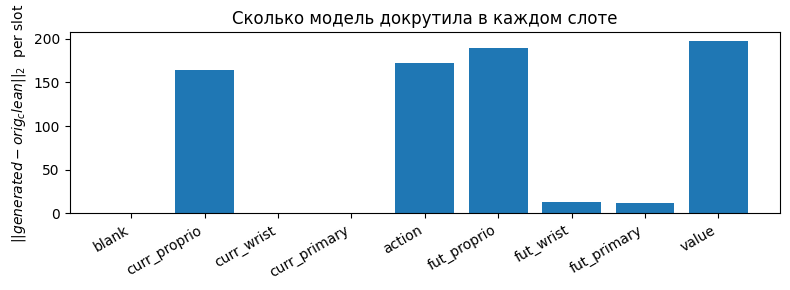

In [32]:
diff = (latent - orig_clean).float()[0]                # (16, 9, 28, 28)
norms = diff.reshape(16, 9, -1).norm(dim=(0, 2))
plt.figure(figsize=(8, 3))
plt.bar(range(9), norms.cpu().numpy())
plt.xticks(range(9), SLOT_NAMES, rotation=30, ha="right")
plt.ylabel("$||generated - orig_clean||_2$  per slot")
plt.title("Сколько модель докрутила в каждом слоте")
plt.tight_layout(); plt.show()

In [39]:
from cosmos_policy.experiments.robot.cosmos_utils import get_action

K = 8
seeds = list(range(100, 100 + K))
ensemble = []
for s in seeds:
    r = get_action(
        cfg, model, dataset_stats, observation, task_description,
        seed=s, num_denoising_steps_action=cfg.num_denoising_steps_action,
        generate_future_state_and_value_in_parallel=True,
    )
    ensemble.append(r)

# (1) value ensemble
vals = np.array([r["value_prediction"] for r in ensemble])
print(f"value ensemble: mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min():.3f}  q10={np.quantile(vals,0.1):.3f}")

# (2) actions ensemble — std per timestep × dim
acts = np.stack([np.array(r["actions"]) for r in ensemble])              # (K, 16, 7)
acts_std = acts.std(axis=0)
print(f"action ensemble std: max={acts_std.max():.4f}, mean={acts_std.mean():.4f}")

# (3) future-image ensemble
imgs = np.stack([r["future_image_predictions"]["future_image"] for r in ensemble]).astype(np.float32)   # (K, 224, 224, 3)
img_mean = imgs.mean(axis=0); img_std = imgs.std(axis=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(observation["primary_image"]);                axes[0].set_title("current obs")
axes[1].imshow(img_mean.astype(np.uint8));                   axes[1].set_title(f"mean future image  (K={K})")
axes[2].imshow(img_std.mean(axis=2), cmap="hot");            axes[2].set_title("uncertainty heatmap (mean over RGB)")
axes[3].imshow(img_std.max(axis=2),  cmap="hot");            axes[3].set_title("max-channel pixel std")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

[05-16 07:49:54|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0


[05-16 07:49:55|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:55|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:56|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:56|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:56|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:57|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
[05-16 07:49:57|INFO|cosmos_policy/_src/imaginaire/modules/res_sampler.py:210:fori_loop] fori_loop: 0
value ensemble: mean=0.999  std=0.000  min=0.999  q10=0.999
action ensemble std: max=0.0151, mean=0.0040


In [45]:
from cosmos_policy.experiments.robot.libero.libero_utils import DATE_TIME, DATE, ImageFont, ImageDraw, Image
import imageio
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg


def _panels_to_strip(width, height, panels_draw, ncol=6):
    """Render `ncol` panels (list of callables ax->None) into one RGB strip
    of exactly (height, width, 3) uint8."""
    dpi = 100
    fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
    for k in range(ncol):
        ax = fig.add_subplot(1, ncol, k + 1)
        try:
            panels_draw[k](ax)
        except Exception as e:  # never let a panel kill the video
            ax.text(0.5, 0.5, f"panel {k}\nerr:{type(e).__name__}",
                    ha="center", va="center", fontsize=7)
            ax.set_axis_off()
    fig.subplots_adjust(left=0.03, right=0.99, top=0.84, bottom=0.12,
                        wspace=0.55)
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    arr = np.asarray(canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    if arr.shape[:2] != (height, width):
        arr = np.array(Image.fromarray(arr).resize((width, height), Image.BILINEAR))
    return arr


_ACT_DIMS = ["dx", "dy", "dz", "dR", "dP", "dY", "grip"]


# ---- no-reference diffusion-artifact / morphing detector ----
def _to_gray(rgb):
    a = np.asarray(rgb).astype(np.float32)
    if a.ndim == 2:
        g = a
    else:
        g = a[..., :3] @ np.array([0.299, 0.587, 0.114], np.float32)
    return g / 255.0 if g.max() > 1.5 else g


def _box(x, r):
    """Fast box blur (radius r) via integral image; reflect-safe enough."""
    if r < 1:
        return x.copy()
    H, W = x.shape
    P = np.zeros((H + 1, W + 1), np.float64)
    P[1:, 1:] = np.cumsum(np.cumsum(x.astype(np.float64), 0), 1)
    # vectorised box sum via integral image
    ii0 = np.clip(np.arange(H) - r, 0, H)
    ii1 = np.clip(np.arange(H) + r + 1, 0, H)
    jj0 = np.clip(np.arange(W) - r, 0, W)
    jj1 = np.clip(np.arange(W) + r + 1, 0, W)
    A = P[ii1][:, jj1] - P[ii0][:, jj1] - P[ii1][:, jj0] + P[ii0][:, jj0]
    cnt = (ii1 - ii0)[:, None] * (jj1 - jj0)[None, :]
    return (A / np.maximum(cnt, 1)).astype(np.float32)


def _gauss(x, sigma=2.0):
    r = max(1, int(round(sigma)))
    y = x
    for _ in range(3):  # 3x box ~= gaussian
        y = _box(y, r)
    return y


def _local_std(x, r=3):
    m = _box(x, r)
    m2 = _box(x * x, r)
    return np.sqrt(np.maximum(m2 - m * m, 0.0))


def artifact_map(rgb, w_cloud=1.0, w_noise=0.6):
    """No-reference NSS / spectral-slope anomaly map.

    Natural images have a ~1/f^2 power spectrum. We estimate a local
    spectral-slope proxy via band-energy ratios and flag regions whose
    slope deviates from this frame's own (robust) natural baseline:
      * over-smooth 'cloud'/morph blobs  -> fine-band energy collapses
        -> slope << baseline  (caught by relu(-dev), weighted w_cloud)
      * grain / sharp diffusion noise    -> slope >> baseline
        -> caught by relu(dev), weighted w_noise
    A soft 'has-structure' gate prevents genuinely flat real surfaces
    (table, wall) from being flagged as clouds.
    """
    g = _to_gray(rgb)
    b1 = _gauss(g, 1.0)
    b4 = _gauss(g, 4.0)
    E_hi = _box(np.abs(g - b1), 4)                    # fine-detail band
    E_mid = _box(np.abs(b1 - b4), 4)                  # mid band (blob structure)
    sharp = E_hi / (E_mid + 1e-4)                     # local spectral flatness
    sharp = _box(sharp, 3)
    # robust frame baseline over CONTENT regions only (ignore dead-flat)
    content = E_mid > (0.20 * np.percentile(E_mid, 95) + 1e-6)
    s0 = np.median(sharp[content]) + 1e-4 if content.any() else np.median(sharp) + 1e-4
    ratio = sharp / s0
    gate = np.tanh(3.0 * E_mid / (np.percentile(E_mid, 75) + 1e-5))  # 0 on flat
    cloud = np.clip(1.0 - ratio, 0, 1)                # E_hi collapsed -> oversmooth/morph
    noise = np.clip(ratio - 1.0, 0, None)             # E_hi excess -> grain
    anom = (w_cloud * cloud + w_noise * np.tanh(noise)) * gate
    a99 = np.percentile(anom, 99) + 1e-6
    anom = np.clip(anom / a99, 0, 1)
    return anom, float(anom.mean())


def _make_bottom_row(diag_list, chunk_idx, total_w, bottom_h,
                     pred_primary=None, pred_wrist=None):
    """Build the 6-panel uncertainty strip for the given chunk."""
    d = diag_list[chunk_idx] if (diag_list is not None and chunk_idx < len(diag_list)) else None
    # value history (per chunk, selected V) up to and including current chunk
    v_hist, vstd_hist = [], []
    if diag_list is not None:
        for e in diag_list[: chunk_idx + 1]:
            if isinstance(e, dict) and "diag_value" in e:
                v_hist.append(float(e["diag_value"]))
                vstd_hist.append(float(e.get("diag_value_std", 0.0)))
    v_now = v_hist[-1] if v_hist else None
    n_seeds = int(d.get("diag_n", 1)) if d else 1

    def _overlay(rgb):
        if rgb is None:
            return None, None
        import matplotlib.cm as _cm
        base = np.asarray(rgb)[..., :3].astype(np.float32)
        if base.max() <= 1.5:
            base = base * 255.0
        amap, score = artifact_map(rgb)
        heat = _cm.inferno(amap)[..., :3] * 255.0
        al = (0.20 + 0.60 * amap)[..., None]          # opaque where anomalous
        comp = (base * (1 - al) + heat * al).clip(0, 255).astype(np.uint8)
        return comp, score

    def _p_one_artifact(ax, rgb, tag):
        comp, score = _overlay(rgb)
        if comp is None:
            ax.text(0.5, 0.5, f"no {tag}\nprediction", ha="center",
                    va="center", fontsize=7)
            ax.set_axis_off()
            ax.set_title(f"{tag} artifact", fontsize=7.5)
            return
        ax.imshow(comp)
        ax.text(4, 14, f"art={score:.3f}", color="w", fontsize=8,
                fontweight="bold", bbox=dict(fc="black", alpha=0.55, pad=2))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{tag} NSS-anom", fontsize=7.5)

    def p_art_primary(ax):
        _p_one_artifact(ax, pred_primary, "primary")

    def p_art_wrist(ax):
        _p_one_artifact(ax, pred_wrist, "wrist")

    def p_vtime(ax):
        if v_hist:
            xs = list(range(len(v_hist)))
            ax.plot(xs, v_hist, "-o", ms=3, color="#1f77b4")
            ax.fill_between(xs,
                            np.array(v_hist) - np.array(vstd_hist),
                            np.array(v_hist) + np.array(vstd_hist),
                            color="#1f77b4", alpha=0.2)
            ax.plot(len(v_hist) - 1, v_hist[-1], "o", ms=7, color="red")
        ax.set_ylim(-0.03, 1.03)
        ax.set_title("V over time (chunks)", fontsize=8)
        ax.tick_params(labelsize=6); ax.grid(alpha=0.3)

    def p_spread(ax):
        vals = d.get("diag_values_all") if d else None
        if vals and len(vals) > 1:
            ax.scatter(np.zeros(len(vals)), vals, s=22, color="#6a3d9a", alpha=0.7)
            m, s = float(np.mean(vals)), float(np.std(vals))
            ax.errorbar(0, m, yerr=s, fmt="_", color="k", capsize=6, lw=2)
            ax.set_title(f"best-of-N spread σ={s:.3f}", fontsize=8)
            ax.set_xlim(-1, 1); ax.set_ylim(-0.03, 1.03); ax.set_xticks([])
            ax.tick_params(labelsize=6)
        else:
            ax.text(0.5, 0.5, f"N={n_seeds}\nset num_queries_best_of_n>1",
                    ha="center", va="center", fontsize=7)
            ax.set_axis_off()
            ax.set_title("best-of-N spread", fontsize=8)

    def p_actchunk(ax):
        ac = d.get("diag_action_chunk") if d else None
        if ac is not None:
            ac = np.asarray(ac)
            im = ax.imshow(ac.T, aspect="auto", cmap="RdBu_r",
                           vmin=-np.abs(ac).max() - 1e-6, vmax=np.abs(ac).max() + 1e-6)
            ax.set_yticks(range(len(_ACT_DIMS))); ax.set_yticklabels(_ACT_DIMS, fontsize=6)
            ax.set_xlabel("chunk step", fontsize=6); ax.tick_params(labelsize=6)
            ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, "no action chunk", ha="center", va="center", fontsize=7)
            ax.set_axis_off()
        ax.set_title("selected action chunk", fontsize=8)

    def p_actstd(ax):
        asd = d.get("diag_action_seed_std") if d else None
        if asd is not None and n_seeds > 1:
            per_dim = np.asarray(asd).reshape(-1, len(_ACT_DIMS)).mean(axis=0) \
                if np.asarray(asd).ndim > 1 else np.asarray(asd)
            ax.bar(range(len(_ACT_DIMS)), per_dim, color="#d1495b")
            ax.set_xticks(range(len(_ACT_DIMS)))
            ax.set_xticklabels(_ACT_DIMS, fontsize=6, rotation=45)
            ax.tick_params(labelsize=6)
        else:
            ax.text(0.5, 0.5, f"N={n_seeds}\nno cross-seed σ",
                    ha="center", va="center", fontsize=7)
            ax.set_axis_off()
        ax.set_title("action disagreement σ", fontsize=8)

    return _panels_to_strip(total_w, bottom_h,
                            [p_art_primary, p_art_wrist, p_vtime, p_spread,
                             p_actchunk, p_actstd])


def save_rollout_video_with_future_image_predictions(
    rollout_images,
    idx,
    success,
    task_description,
    chunk_size,
    num_open_loop_steps,
    rollout_wrist_images=None,
    future_primary_image_predictions=None,
    future_wrist_image_predictions=None,
    show_diff=False,
    log_file=None,
    future_diagnostics_list=None,
    show_uncertainty_row=True,
):
    """Saves an MP4 replay of an episode with future image predictions shown on the
    right, plus (optional) a bottom row of well-founded uncertainty panels:
      primary artifact map | wrist artifact map | V-over-time |
      best-of-N value spread | action chunk | action cross-seed disagreement."""
    rollout_dir = f"./rollouts/{DATE}"
    os.makedirs(rollout_dir, exist_ok=True)
    processed_task_description = task_description.lower().replace(" ", "_").replace("\n", "_").replace(".", "_")[:35]
    mp4_path = f"{rollout_dir}/{DATE_TIME}--with_future_img--episode={idx}--success={success}--task={processed_task_description}.mp4"
    video_writer = imageio.get_writer(mp4_path, fps=30)

    has_primary_predictions = future_primary_image_predictions is not None and len(future_primary_image_predictions) > 0
    has_wrist_replay = rollout_wrist_images is not None
    has_wrist_predictions = has_wrist_replay and (
        future_wrist_image_predictions is not None and len(future_wrist_image_predictions) > 0
    )

    if has_primary_predictions:
        target_h, target_w, c = future_primary_image_predictions[0].shape
    elif has_wrist_predictions:
        target_h, target_w, c = future_wrist_image_predictions[0].shape
    else:
        target_h, target_w, c = rollout_images[0].shape

    text_height = 60
    font_size = 18

    if show_diff:
        column_labels = []
        if has_wrist_replay:
            column_labels.append("replay wrist")
        if has_wrist_predictions:
            column_labels.append("future wrist")
            column_labels.append("wrist difference")
        column_labels.append("replay primary")
        if has_primary_predictions:
            column_labels.append("future primary")
            column_labels.append("primary difference")
    else:
        column_labels = []
        if has_wrist_replay:
            column_labels.append("real wrist image")
        if has_wrist_predictions:
            column_labels.append("predicted wrist image")
        column_labels.append("real current image")
        if has_primary_predictions:
            column_labels.append("predicted future image")
    num_columns = len(column_labels)

    if has_wrist_replay:
        image_iterator = zip(rollout_images, rollout_wrist_images)
    else:
        image_iterator = rollout_images

    total_w = target_w * num_columns
    bottom_h = target_h
    do_bottom = show_uncertainty_row and (future_diagnostics_list is not None)
    brow_cache = {}

    for i, image_data in enumerate(image_iterator):
        if has_wrist_replay:
            img, wrist_img = image_data
        else:
            img = image_data

        if img.shape[:2] != (target_h, target_w):
            img = np.array(Image.fromarray(img).resize((target_w, target_h), Image.LANCZOS))

        if has_wrist_replay:
            if wrist_img.shape[:2] != (target_h, target_w):
                wrist_img = np.array(Image.fromarray(wrist_img).resize((target_w, target_h), Image.LANCZOS))

        chunk_idx = i // num_open_loop_steps
        target_real_idx = (chunk_idx + 1) * num_open_loop_steps - 1
        target_real_idx = min(target_real_idx, len(rollout_images) - 1)

        future_img = None
        future_wrist_img = None
        if has_primary_predictions and chunk_idx < len(future_primary_image_predictions):
            future_img = future_primary_image_predictions[chunk_idx]
        if has_wrist_predictions and chunk_idx < len(future_wrist_image_predictions):
            future_wrist_img = future_wrist_image_predictions[chunk_idx]

        def _resize_to_target(arr):
            if arr.shape[:2] != (target_h, target_w):
                return np.array(Image.fromarray(arr).resize((target_w, target_h), Image.LANCZOS))
            return arr

        real_primary_at_target = _resize_to_target(rollout_images[target_real_idx]) if has_primary_predictions else None
        real_wrist_at_target = _resize_to_target(rollout_wrist_images[target_real_idx]) if has_wrist_replay else None

        blank = np.zeros((target_h, target_w, c), dtype=np.uint8)
        primary_diff = blank.copy()
        wrist_diff = blank.copy()
        if show_diff:
            if has_primary_predictions and future_img is not None and real_primary_at_target is not None:
                primary_diff = np.clip(np.abs(real_primary_at_target.astype(np.float32) - future_img.astype(np.float32)), 0, 255).astype(np.uint8)
            if has_wrist_predictions and future_wrist_img is not None and real_wrist_at_target is not None:
                wrist_diff = np.clip(np.abs(real_wrist_at_target.astype(np.float32) - future_wrist_img.astype(np.float32)), 0, 255).astype(np.uint8)

        combined_img = np.zeros((target_h, target_w * num_columns, c), dtype=np.uint8)
        col = 0
        if show_diff:
            if has_wrist_replay:
                combined_img[:, target_w * col:target_w * (col + 1), :] = wrist_img
                col += 1
            if has_wrist_predictions and future_wrist_img is not None:
                combined_img[:, target_w * col:target_w * (col + 1), :] = future_wrist_img
                col += 1
                combined_img[:, target_w * col:target_w * (col + 1), :] = wrist_diff
                col += 1
            combined_img[:, target_w * col:target_w * (col + 1), :] = img
            col += 1
            if has_primary_predictions and future_img is not None:
                combined_img[:, target_w * col:target_w * (col + 1), :] = future_img
                col += 1
                combined_img[:, target_w * col:target_w * (col + 1), :] = primary_diff
                col += 1
        else:
            if has_wrist_replay:
                combined_img[:, target_w * col:target_w * (col + 1), :] = wrist_img
                col += 1
            if has_wrist_predictions and future_wrist_img is not None:
                combined_img[:, target_w * col:target_w * (col + 1), :] = future_wrist_img
                col += 1
            combined_img[:, target_w * col:target_w * (col + 1), :] = img
            col += 1
            if has_primary_predictions and future_img is not None:
                combined_img[:, target_w * col:target_w * (col + 1), :] = future_img
                col += 1

        text_area = np.ones((text_height, target_w * num_columns, 3), dtype=np.uint8) * 255
        text_img = Image.fromarray(text_area)
        draw = ImageDraw.Draw(text_img)
        try:
            font = ImageFont.truetype("Arial", font_size)
        except IOError:
            try:
                font = ImageFont.truetype("DejaVuSans", font_size)
            except IOError:
                try:
                    font = ImageFont.truetype("Verdana", font_size)
                except IOError:
                    font = ImageFont.load_default()

        for col_idx, label in enumerate(column_labels):
            x_pos = col_idx * target_w + target_w // 2
            text_width = draw.textlength(label, font=font)
            draw.text((x_pos - text_width // 2, 8), label, font=font, fill=(0, 0, 0))
            if ("predicted" in label) or ("future" in label):
                k_text = f"(K={chunk_size} timesteps)"
                k_text_width = draw.textlength(k_text, font=font)
                draw.text((x_pos - k_text_width // 2, 35), k_text, font=font, fill=(0, 0, 0))

        timestep_text = f"t = {i}"
        timestep_text_width = draw.textlength(timestep_text, font=font)
        center_x = (target_w * num_columns) // 2
        draw.text((center_x - timestep_text_width // 2, 36), timestep_text, font=font, fill=(255, 0, 0))
        text_area = np.array(text_img)

        final_frame = np.vstack((text_area, combined_img))

        if do_bottom:
            if chunk_idx not in brow_cache:
                brow_cache[chunk_idx] = _make_bottom_row(
                    future_diagnostics_list, chunk_idx, total_w, bottom_h,
                    pred_primary=future_img, pred_wrist=future_wrist_img)
            final_frame = np.vstack((final_frame, brow_cache[chunk_idx]))

        video_writer.append_data(final_frame)

    video_writer.close()
    print(f"Saved rollout MP4 at path {mp4_path}")
    if log_file is not None:
        log_file.write(f"Saved rollout MP4 at path {mp4_path}\n")
    return mp4_path


In [46]:
future_primary_image_predictions = None
if cfg.use_third_person_image:
    future_primary_image_predictions = [x["future_image"] for x in future_image_predictions_list]
future_wrist_image_predictions = None
if cfg.use_wrist_image:
    future_wrist_image_predictions = [x["future_wrist_image"] for x in future_image_predictions_list]
print(len(future_primary_image_predictions), "chunks; primary shape",
      future_primary_image_predictions[0].shape)


33 chunks; primary shape (224, 224, 3)


In [47]:
save_rollout_video_with_future_image_predictions(
            replay_images,
            0,
            success=success,
            task_description=task_description,
            chunk_size=cfg.chunk_size,
            num_open_loop_steps=cfg.num_open_loop_steps,
            rollout_wrist_images=replay_wrist_images,
            future_primary_image_predictions=future_primary_image_predictions,
            future_wrist_image_predictions=future_wrist_image_predictions,
            future_diagnostics_list=future_image_predictions_list,
            show_uncertainty_row=True,
            show_diff=True,
        )

Saved rollout MP4 at path ./rollouts/2026_05_16/2026_05_16-07_23_43--with_future_img--episode=0--success=False--task=put_the_white_mug_on_the_left_plate.mp4


'./rollouts/2026_05_16/2026_05_16-07_23_43--with_future_img--episode=0--success=False--task=put_the_white_mug_on_the_left_plate.mp4'